# EDA: Longitudinal 1H-NMR Metabolomics Dataset MTBLS242

Notebook นี้ทำ EDA สำหรับข้อมูล serum 1H-NMR metabolomics จากไฟล์ `Domain_2_sample_table_MTBLS242.tsv` และ `Domain_2_NMR_results_MTBLS242.tsv` โดยมองข้อมูลเป็น repeated-measures / longitudinal dataset: subject เดิมถูกวัดหลาย time point ตั้งแต่ `preop` ถึง `12 months after surgery`.

แนวทางหลัก:
- reshape NMR abundance จาก metabolite x sample matrix ให้เป็น sample x metabolite table
- merge กับ metadata จาก `Sample Name`
- ตรวจ QC: missing, zero, distribution และ outlier
- ใช้ `log1p` transformation ก่อน PCA/heatmap/boxplot เพราะ abundance กระจายกว้างมาก
- ใช้กราฟที่อ่านง่ายและใช้สีแบบ colorblind-friendly
- ใช้สถิติแบบ paired/repeated-measures เช่น Friedman test และ Wilcoxon signed-rank แทน one-way ANOVA แบบ independent


## Research References

Paper ที่ตรงกับข้อมูลนี้มากที่สุดคือ Gralka et al. (2015) เพราะเป็นการศึกษา serum 1H-NMR metabolomics ใน severe obesity ก่อนและหลัง bariatric surgery แบบ longitudinal และติดตามถึง 12 เดือน ซึ่งตรงกับ time points ใน dataset นี้โดยตรง.

References:
1. Gralka E, Luchinat C, Tenori L, Ernst B, Thurnheer M, Schultes B. **Metabolomic fingerprint of severe obesity is dynamically affected by bariatric surgery in a procedure-dependent manner.** *The American Journal of Clinical Nutrition.* 2015;102(6):1313-1322. doi:[10.3945/ajcn.115.110536](https://doi.org/10.3945/ajcn.115.110536)
2. van den Berg RA, Hoefsloot HCJ, Westerhuis JA, Smilde AK, van der Werf MJ. **Centering, scaling, and transformations: improving the biological information content of metabolomics data.** *BMC Genomics.* 2006;7:142. doi:[10.1186/1471-2164-7-142](https://doi.org/10.1186/1471-2164-7-142)
3. Madssen TS, Giskeødegård GF, Smilde AK, Westerhuis JA. **Repeated measures ASCA+ for analysis of longitudinal intervention studies with multivariate outcome data.** *PLOS Computational Biology.* 2021;17(11):e1009585. doi:[10.1371/journal.pcbi.1009585](https://doi.org/10.1371/journal.pcbi.1009585)


## 1. Setup

Cell นี้เตรียม package, ตั้งค่า plot style, และกำหนดสีสำหรับ time point ให้มองง่าย สีที่ใช้เป็น colorblind-friendly palette เพื่อให้กราฟอ่านง่ายขึ้นทั้งบนจอและเวลานำไปใส่สไลด์.


In [44]:
from pathlib import Path
import os
import re
import math
import warnings

# Keep matplotlib cache inside the project so plots do not fail on systems
# where the default user cache directory is not writable.
MPLCONFIGDIR = Path('.matplotlib_cache').resolve()
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

try:
    from scipy.stats import friedmanchisquare as scipy_friedmanchisquare
    from scipy.stats import wilcoxon as scipy_wilcoxon
    SCIPY_AVAILABLE = True
except ModuleNotFoundError:
    scipy_friedmanchisquare = None
    scipy_wilcoxon = None
    SCIPY_AVAILABLE = False

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TIME_ORDER = [
    'preop',
    '3 months after surgery',
    '6 months after surgery',
    '9 months after surgery',
    '12 months after surgery',
]

# Okabe-Ito-inspired colors: high contrast and colorblind-friendly.
TIME_PALETTE = {
    'preop': '#0072B2',                    # blue
    '3 months after surgery': '#009E73',   # green
    '6 months after surgery': '#E69F00',   # orange
    '9 months after surgery': '#D55E00',   # vermillion
    '12 months after surgery': '#CC79A7',  # reddish purple
}

DATA_DIR = Path('.')
SAMPLE_PATH = DATA_DIR / 'Domain_2_sample_table_MTBLS242.tsv'
NMR_PATH = DATA_DIR / 'Domain_2_NMR_results_MTBLS242.tsv'
OUTPUT_DIR = DATA_DIR / 'eda_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)


def zscore_1d(values):
    """Return z-scores without requiring scipy."""
    series = pd.Series(values, dtype='float64')
    mean = series.mean(skipna=True)
    std = series.std(skipna=True, ddof=0)
    if not np.isfinite(std) or std == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - mean) / std


def standardize_matrix(frame):
    """Column-wise z-score standardization without sklearn."""
    arr = frame.to_numpy(dtype=float)
    means = np.nanmean(arr, axis=0)
    stds = np.nanstd(arr, axis=0, ddof=0)
    stds[~np.isfinite(stds) | (stds == 0)] = 1.0
    scaled = (arr - means) / stds
    return np.nan_to_num(scaled, nan=0.0)


def pca_via_svd(matrix, n_components=5):
    """PCA scores/loadings using NumPy SVD, equivalent to PCA on centered data."""
    x = np.asarray(matrix, dtype=float)
    x = x - np.nanmean(x, axis=0)
    x = np.nan_to_num(x, nan=0.0)
    u, s, vt = np.linalg.svd(x, full_matrices=False)
    n_components = min(n_components, vt.shape[0])
    scores = u[:, :n_components] * s[:n_components]
    variances = (s ** 2) / max(x.shape[0] - 1, 1)
    variance_ratio = variances / variances.sum()
    components = vt[:n_components, :]
    return scores, variance_ratio[:n_components], components


def _chi_square_sf_even_df(x, df):
    """Survival function for chi-square when df is even; fallback for Friedman p-values."""
    if not np.isfinite(x) or x < 0:
        return np.nan
    if df > 0 and df % 2 == 0:
        half_x = x / 2
        terms = sum((half_x ** j) / math.factorial(j) for j in range(df // 2))
        return float(math.exp(-half_x) * terms)
    # Wilson-Hilferty normal approximation for uncommon non-even df cases.
    z = ((x / df) ** (1 / 3) - (1 - 2 / (9 * df))) / math.sqrt(2 / (9 * df))
    return float(0.5 * math.erfc(z / math.sqrt(2)))


def friedman_test(*groups):
    """Friedman test using scipy if available, otherwise a rank-based fallback."""
    if SCIPY_AVAILABLE:
        return scipy_friedmanchisquare(*groups)

    data = np.vstack([np.asarray(g, dtype=float) for g in groups]).T
    data = data[np.isfinite(data).all(axis=1)]
    n, k = data.shape if data.size else (0, 0)
    if n == 0 or k < 2:
        return np.nan, np.nan

    ranks = pd.DataFrame(data).rank(axis=1, method='average').to_numpy()
    rank_sums = ranks.sum(axis=0)
    statistic = (12 / (n * k * (k + 1))) * np.sum(rank_sums ** 2) - 3 * n * (k + 1)

    tie_sum = 0
    for row in data:
        _, counts = np.unique(row, return_counts=True)
        tie_sum += np.sum(counts ** 3 - counts)
    correction = 1 - tie_sum / (n * k * (k ** 2 - 1))
    if correction > 0:
        statistic = statistic / correction

    p_value = _chi_square_sf_even_df(statistic, k - 1)
    return float(statistic), float(p_value)


def _normal_cdf(x):
    return 0.5 * math.erfc(-x / math.sqrt(2))


def paired_wilcoxon_test(after, before):
    """Wilcoxon signed-rank test; scipy when available, normal-approx fallback otherwise."""
    after = np.asarray(after, dtype=float)
    before = np.asarray(before, dtype=float)
    if SCIPY_AVAILABLE:
        stat, p_value = scipy_wilcoxon(after, before, zero_method='wilcox')
        return float(stat), float(p_value), 'wilcoxon_scipy'

    diff = after - before
    diff = diff[np.isfinite(diff) & (diff != 0)]
    n = len(diff)
    if n == 0:
        return np.nan, np.nan, 'wilcoxon_fallback_normal_approx'

    ranks = pd.Series(np.abs(diff)).rank(method='average').to_numpy()
    w_plus = ranks[diff > 0].sum()
    w_minus = ranks[diff < 0].sum()
    statistic = min(w_plus, w_minus)

    mean_w = n * (n + 1) / 4
    var_w = n * (n + 1) * (2 * n + 1) / 24
    _, tie_counts = np.unique(np.abs(diff), return_counts=True)
    var_w -= np.sum(tie_counts ** 3 - tie_counts) / 48
    if var_w <= 0:
        return float(statistic), np.nan, 'wilcoxon_fallback_normal_approx'

    # Continuity correction toward the mean.
    correction = 0.5 if statistic < mean_w else -0.5
    z = (statistic - mean_w + correction) / math.sqrt(var_w)
    p_value = 2 * min(_normal_cdf(z), 1 - _normal_cdf(z))
    return float(statistic), float(min(max(p_value, 0.0), 1.0)), 'wilcoxon_fallback_normal_approx'

print(f'SciPy available: {SCIPY_AVAILABLE}')


SciPy available: False


## 2. Load Data

อ่าน sample metadata และ NMR result table จาก TSV แล้วดูขนาดข้อมูลเบื้องต้น จุดสำคัญคือ NMR table มี metadata ของ metabolite อยู่ด้านซ้าย และคอลัมน์ abundance ของแต่ละ sample อยู่ด้านขวา.


In [23]:
sample = pd.read_csv(SAMPLE_PATH, sep='\t')
nmr = pd.read_csv(NMR_PATH, sep='\t')

print(f'sample table shape: {sample.shape}')
print(f'NMR results shape: {nmr.shape}')

display(sample.head())
display(nmr.iloc[:, :18].head())


sample table shape: (465, 18)
NMR results shape: (21, 483)


,Source Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Organism part],Term Source REF.1,Term Accession Number.1,Characteristics[Variant],Term Source REF.2,Term Accession Number.2,Characteristics[Sample type],Term Source REF.3,Term Accession Number.3,Protocol REF,Sample Name,Factor Value[time point],Term Source REF.4,Term Accession Number.4
0,blood,Homo sapiens,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,blood serum,BTO,http://purl.obolibrary.org/obo/BTO_0000133,NaN,NaN,NaN,NaN,NaN,NaN,Sample collection,0_0001_S,preop,HL7,http://purl.bioontology.org/ontology/HL7/C1555329
1,blood,Homo sapiens,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,blood serum,BTO,http://purl.obolibrary.org/obo/BTO_0000133,NaN,NaN,NaN,NaN,NaN,NaN,Sample collection,0_0002_S,preop,HL7,http://purl.bioontology.org/ontology/HL7/C1555329
2,blood,Homo sapiens,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,blood serum,BTO,http://purl.obolibrary.org/obo/BTO_0000133,NaN,NaN,NaN,NaN,NaN,NaN,Sample collection,0_0003_S,preop,HL7,http://purl.bioontology.org/ontology/HL7/C1555329
3,blood,Homo sapiens,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,blood serum,BTO,http://purl.obolibrary.org/obo/BTO_0000133,NaN,NaN,NaN,NaN,NaN,NaN,Sample collection,0_0004_S,preop,HL7,http://purl.bioontology.org/ontology/HL7/C1555329
4,blood,Homo sapiens,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,blood serum,BTO,http://purl.obolibrary.org/obo/BTO_0000133,NaN,NaN,NaN,NaN,NaN,NaN,Sample collection,0_0008_S,preop,HL7,http://purl.bioontology.org/ontology/HL7/C1555329


,database_identifier,chemical_formula,smiles,inchi,metabolite_identification,chemical_shift,multiplicity,taxid,species,database,database_version,reliability,uri,search_engine,search_engine_score,smallmolecule_abundance_sub,smallmolecule_abundance_stdev_sub,smallmolecule_abundance_std_error_sub
0,CHEBI:17066,C4H8O3,C[C@@H](O)CC(O)=O,"InChI=1S/C4H8O3/c1-3(5)2-4(6)7/h3,5H,2H2,1H3,(...",(R)-3-Hydroxybutyric acid,NaN,NaN,NCBITAXON:http://purl.bioontology.org/ontology...,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEBI:15366,C2H4O2,CC(O)=O,"InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)",acetate,NaN,NaN,NCBITAXON:http://purl.bioontology.org/ontology...,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEBI:15344,C4H6O3,CC(=O)CC(O)=O,"InChI=1S/C4H6O3/c1-3(5)2-4(6)7/h2H2,1H3,(H,6,7)",acetoacetate,NaN,NaN,NCBITAXON:http://purl.bioontology.org/ontology...,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHEBI:16977,C3H7NO2,C[C@H](N)C(O)=O,"InChI=1S/C3H7NO2/c1-2(4)3(5)6/h2H,4H2,1H3,(H,5...",L-alanine,NaN,NaN,NCBITAXON:http://purl.bioontology.org/ontology...,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHEBI:16414,C5H11NO2,CC(C)[C@H](N)C(O)=O,"InChI=1S/C5H11NO2/c1-3(2)4(6)5(7)8/h3-4H,6H2,1...",L-valine,NaN,NaN,NCBITAXON:http://purl.bioontology.org/ontology...,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Reshape NMR Matrix and Merge Metadata

NMR results อยู่ในรูป metabolite x sample จึง transpose ให้เป็น sample x metabolite ก่อน จากนั้น merge ด้วย `Sample Name`. เราดึง `subject_id` จากชื่อ sample เพื่อใช้กับ repeated-measures analysis.


In [24]:
def extract_subject_id(sample_name):
    """Extract subject id from names such as 0_0001_S, 0-0671-S, or 2_0242_2."""
    clean_name = str(sample_name).strip().replace('-', '_')
    parts = clean_name.split('_')
    return parts[1] if len(parts) >= 2 else np.nan

meta_end = nmr.columns.get_loc('smallmolecule_abundance_std_error_sub') + 1
abund_cols = list(nmr.columns[meta_end:])
metabs = list(nmr['metabolite_identification'])

# Validate that sample columns in the NMR table match the sample metadata.
metadata_samples = set(sample['Sample Name'].astype(str))
nmr_samples = set(map(str, abund_cols))
print(f'NMR abundance sample columns: {len(abund_cols):,}')
print(f'Matched samples: {len(metadata_samples & nmr_samples):,} / {len(metadata_samples):,}')
print(f'NMR-only samples: {len(nmr_samples - metadata_samples):,}')
print(f'metadata-only samples: {len(metadata_samples - nmr_samples):,}')

X = nmr[abund_cols].T.apply(pd.to_numeric, errors='coerce')
X.columns = metabs
X.index.name = 'Sample Name'

metadata_cols = ['Sample Name', 'Factor Value[time point]']
df = sample[metadata_cols].merge(X, left_on='Sample Name', right_index=True, how='inner')

df['time_order'] = df['Sample Name'].astype(str).str.extract(r'^(\d)').astype(int)
df['time_point'] = pd.Categorical(df['Factor Value[time point]'], categories=TIME_ORDER, ordered=True)
df['subject_id'] = df['Sample Name'].map(extract_subject_id)

print(f'reshaped data shape: {df.shape}')
display(df[['Sample Name', 'subject_id', 'time_point'] + metabs[:5]].head())


NMR abundance sample columns: 465
Matched samples: 465 / 465
NMR-only samples: 0
metadata-only samples: 0
reshaped data shape: (465, 26)


,Sample Name,subject_id,time_point,(R)-3-Hydroxybutyric acid,acetate,acetoacetate,L-alanine,L-valine
0,0_0001_S,0001,preop,5.847646,77.303766,60.508736,1417.944839,302.955510
1,0_0002_S,0002,preop,0.965908,45.779248,79.485809,1007.048134,334.462203
2,0_0003_S,0003,preop,6.712743,122.149735,56.914505,1033.135943,315.909012
3,0_0004_S,0004,preop,0.000000,22.453666,28.919573,1140.332866,276.548826
4,0_0008_S,0008,preop,0.000000,77.442927,31.107538,1155.909608,367.524066


## 4. Dataset Overview

เช็กจำนวน sample ต่อ time point และจำนวน time point ต่อ subject เพื่อรู้ว่า repeated-measures design สมบูรณ์แค่ไหน. ข้อมูลนี้ไม่ควรถูกวิเคราะห์เหมือน sample ทุกแถวเป็น independent เพราะ subject เดิมมีการวัดซ้ำ.


In [25]:
time_counts = df['time_point'].value_counts().reindex(TIME_ORDER)
subject_time_counts = df.groupby('subject_id', observed=True)['time_point'].nunique()

summary = pd.DataFrame({
    'metric': [
        'samples',
        'metabolites',
        'subjects',
        'subjects with all 5 time points',
        'missing abundance values',
        'zero abundance values',
    ],
    'value': [
        len(df),
        len(metabs),
        df['subject_id'].nunique(),
        int((subject_time_counts == 5).sum()),
        int(df[metabs].isna().sum().sum()),
        int((df[metabs] == 0).sum().sum()),
    ]
})

display(summary)
display(time_counts.rename('n_samples').to_frame())
display(subject_time_counts.value_counts().sort_index().rename('n_subjects').to_frame())


,metric,value
0,samples,465
1,metabolites,21
2,subjects,107
3,subjects with all 5 time points,60
4,missing abundance values,0
5,zero abundance values,164


,n_samples
time_point,
preop,106
3 months after surgery,98
6 months after surgery,98
9 months after surgery,92
12 months after surgery,71


,n_subjects
time_point,
1,2
2,7
3,3
4,35
5,60


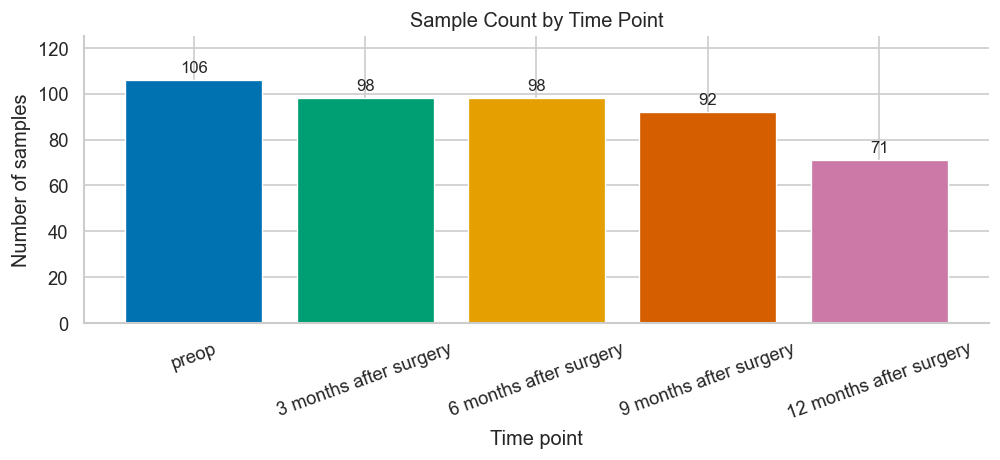

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 4))
colors = [TIME_PALETTE[t] for t in TIME_ORDER]
ax.bar(time_counts.index.astype(str), time_counts.values, color=colors, edgecolor='white', linewidth=0.8)

for i, value in enumerate(time_counts.values):
    ax.text(i, value + 2, str(int(value)), ha='center', va='bottom', fontsize=10)

ax.set_title('Sample Count by Time Point')
ax.set_xlabel('Time point')
ax.set_ylabel('Number of samples')
ax.set_ylim(0, max(time_counts.values) * 1.18)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 5. QC: Missing and Zero Values

สำหรับ metabolomics data ค่า missing/zero มีผลกับ transformation และสถิติ downstream จึงเช็กทั้งภาพรวมและระดับ metabolite. ใน dataset นี้ missing abundance เป็นศูนย์ แต่ zero มีบาง metabolite ที่ควรระวัง โดยเฉพาะ metabolite ที่มี zero สูง.


In [27]:
zero_summary = pd.DataFrame({
    'metabolite': metabs,
    'missing_n': df[metabs].isna().sum().values,
    'missing_pct': df[metabs].isna().mean().mul(100).values,
    'zero_n': (df[metabs] == 0).sum().values,
    'zero_pct': (df[metabs] == 0).mean().mul(100).values,
    'mean': df[metabs].mean().values,
    'median': df[metabs].median().values,
})
zero_summary = zero_summary.sort_values('zero_pct', ascending=False)
display(zero_summary.round(3))


,metabolite,missing_n,missing_pct,zero_n,zero_pct,mean,median
0,(R)-3-Hydroxybutyric acid,0,0.0,143,30.753,26.320,7.358
5,hypoxanthine,0,0.0,7,1.505,5.322,4.742
6,citrate,0,0.0,5,1.075,112.674,113.709
12,isopropanol,0,0.0,3,0.645,69.009,38.439
2,acetoacetate,0,0.0,3,0.645,86.307,58.529
19,Pyruvic acid,0,0.0,1,0.215,99.180,88.568
17,Dimethyl sulfone,0,0.0,1,0.215,84.207,59.160
13,L-Lactic acid,0,0.0,1,0.215,1847.504,1781.479
18,D-phenylalanine,0,0.0,0,0.000,139.333,136.552
16,methanol,0,0.0,0,0.000,242.393,168.273


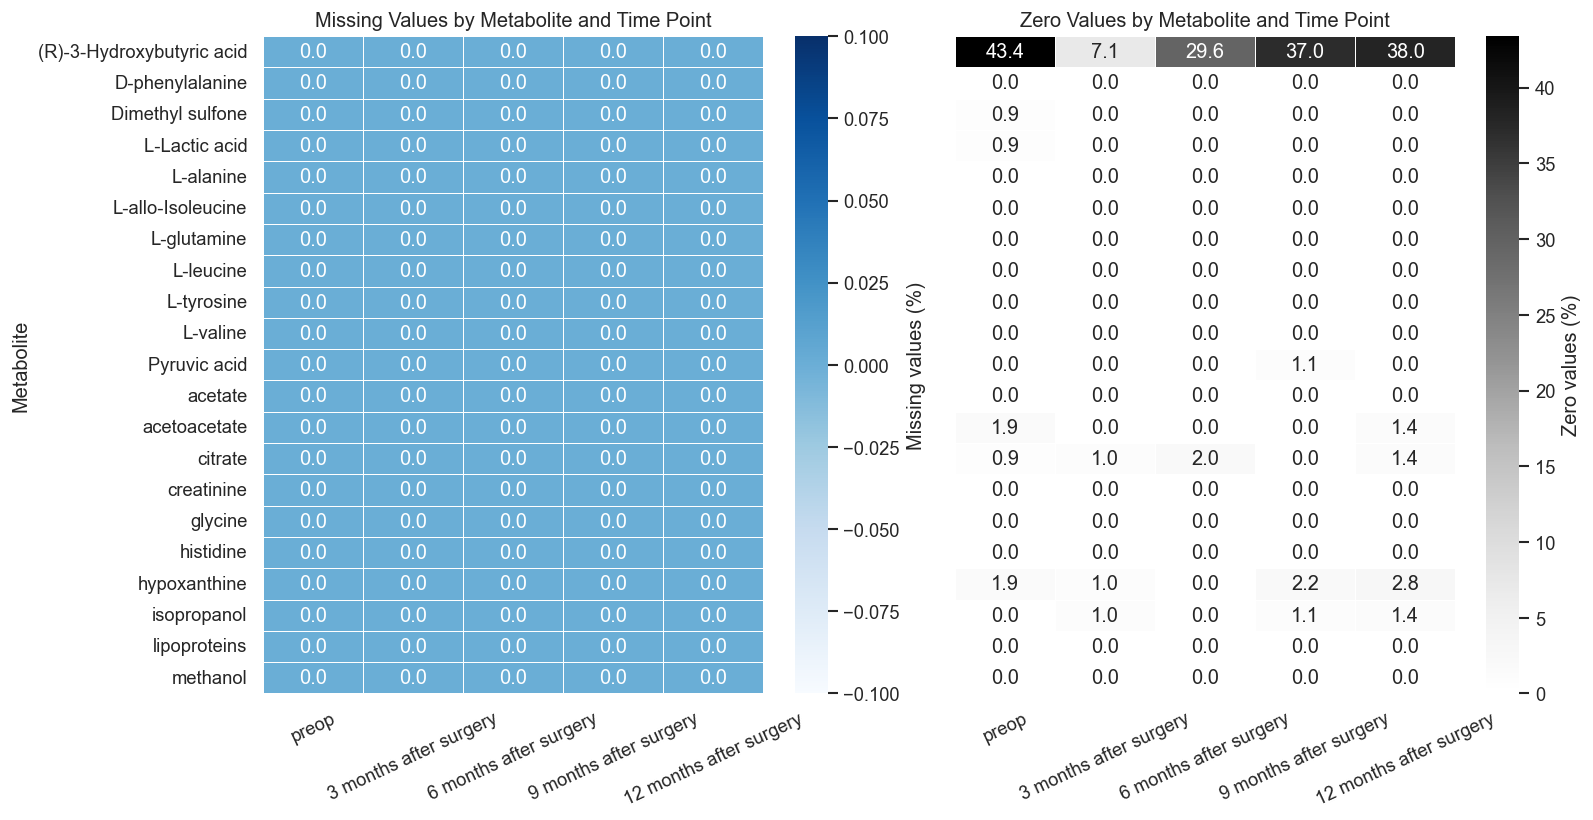

In [28]:
long_qc = df[['Sample Name', 'time_point'] + metabs].melt(
    id_vars=['Sample Name', 'time_point'],
    value_vars=metabs,
    var_name='metabolite',
    value_name='abundance',
)
long_qc['is_zero'] = long_qc['abundance'].eq(0)
long_qc['is_missing'] = long_qc['abundance'].isna()

zero_heat = (
    long_qc.groupby(['metabolite', 'time_point'], observed=True)['is_zero']
    .mean()
    .mul(100)
    .unstack('time_point')
    .reindex(columns=TIME_ORDER)
)
missing_heat = (
    long_qc.groupby(['metabolite', 'time_point'], observed=True)['is_missing']
    .mean()
    .mul(100)
    .unstack('time_point')
    .reindex(columns=TIME_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7), sharey=True)
sns.heatmap(
    missing_heat,
    ax=axes[0],
    cmap='Blues',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Missing values (%)'},
)
axes[0].set_title('Missing Values by Metabolite and Time Point')
axes[0].set_xlabel('')
axes[0].set_ylabel('Metabolite')

sns.heatmap(
    zero_heat,
    ax=axes[1],
    cmap='Greys',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Zero values (%)'},
)
axes[1].set_title('Zero Values by Metabolite and Time Point')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

for ax in axes:
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


## 6. Log Transform and Distribution Check

ใช้ `log1p(x)` แทน `log(x)` เพราะข้อมูลมีค่า zero บางส่วน การ transform นี้ช่วยลด skew และทำให้ metabolite ที่ abundance สูงมาก เช่น lipoproteins ไม่ครอบงำ PCA/heatmap มากเกินไป.


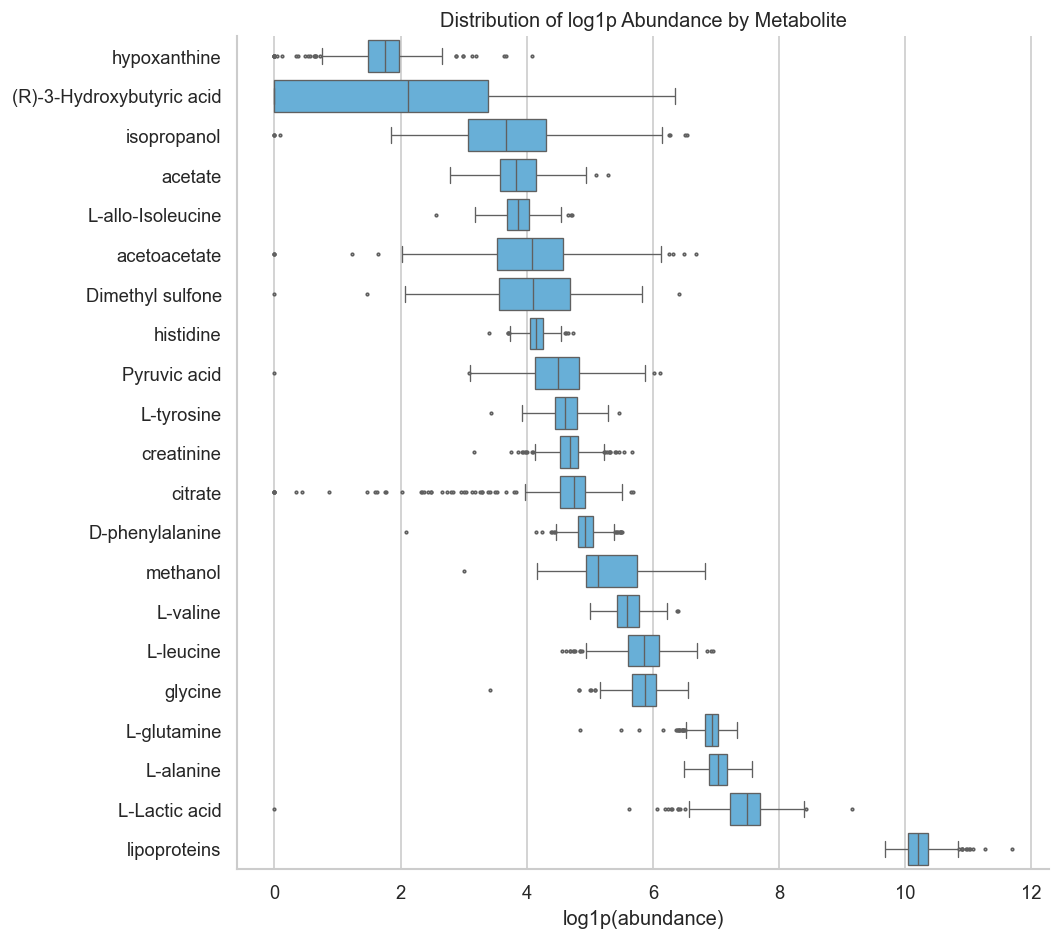

In [29]:
df_log = df.copy()
df_log[metabs] = np.log1p(df_log[metabs])

long_log = df_log[['Sample Name', 'subject_id', 'time_point'] + metabs].melt(
    id_vars=['Sample Name', 'subject_id', 'time_point'],
    value_vars=metabs,
    var_name='metabolite',
    value_name='log1p_abundance',
)

fig, ax = plt.subplots(figsize=(9, 8))
metabolite_order = df_log[metabs].median().sort_values().index
sns.boxplot(
    data=long_log,
    y='metabolite',
    x='log1p_abundance',
    order=metabolite_order,
    color='#56B4E9',
    fliersize=1.5,
    linewidth=0.8,
    ax=ax,
)
ax.set_title('Distribution of log1p Abundance by Metabolite')
ax.set_xlabel('log1p(abundance)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 6.1 Heatmap of log1p Abundance

Heatmap นี้ใช้ค่า median ของ `log1p(abundance)` แยกตาม metabolite และ time point เพื่อดูภาพรวมหลัง log transform แบบอ่านง่าย สีเข้มคือ abundance หลัง log transform สูงกว่าใน matrix นี้. ถ้าต้องการเปรียบเทียบ pattern ข้าม metabolite แบบเท่า scale ให้ดู heatmap แบบ z-score ใน section ถัดไป.


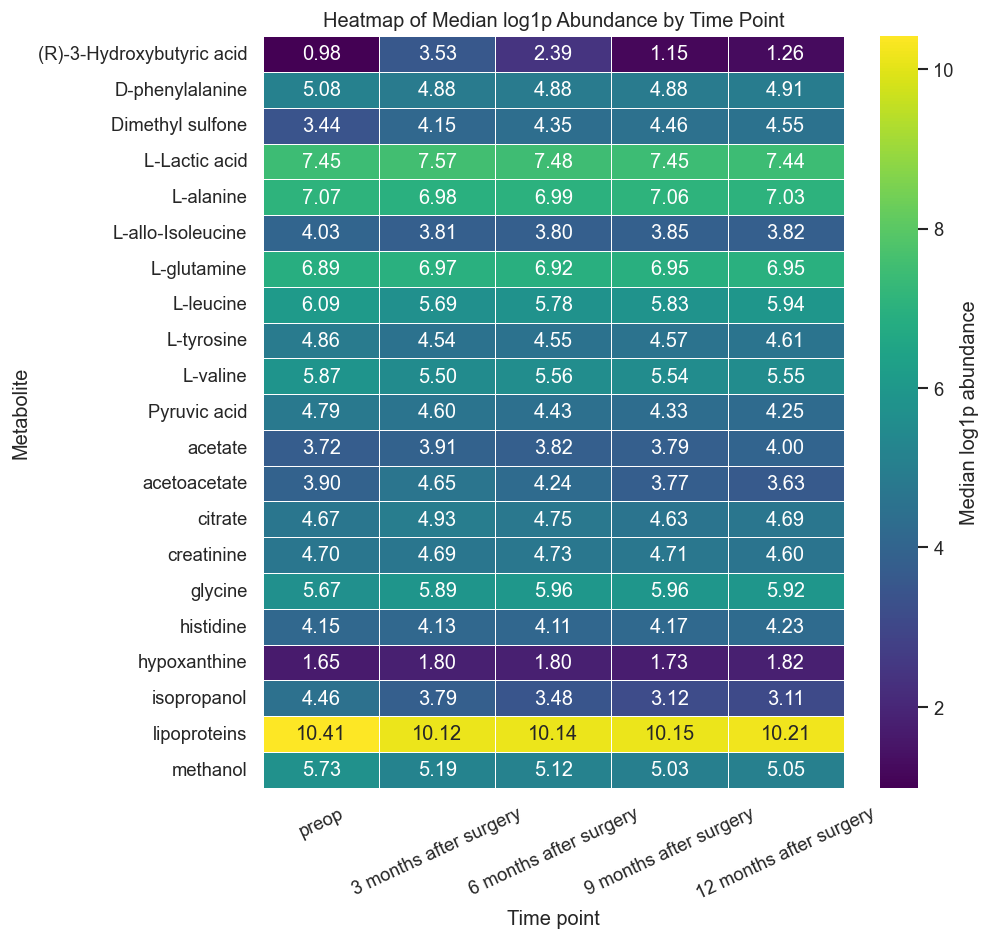

In [46]:
log_heatmap = (
    long_log.groupby(['metabolite', 'time_point'], observed=True)['log1p_abundance']
    .median()
    .unstack('time_point')
    .reindex(columns=TIME_ORDER)
)

fig, ax = plt.subplots(figsize=(8.5, 8))
sns.heatmap(
    log_heatmap,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    linewidths=0.35,
    cbar_kws={'label': 'Median log1p abundance'},
    ax=ax,
)
ax.set_title('Heatmap of Median log1p Abundance by Time Point')
ax.set_xlabel('Time point')
ax.set_ylabel('Metabolite')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## 7. Sample-Level Outlier Check

เช็ก outlier จาก total abundance หลัง log transform แบบง่าย ๆ โดยใช้ z-score ของ `log1p(total abundance)`. ค่า `|z| > 3` เป็น flag เบื้องต้น ไม่ได้แปลว่าต้องลบ sample ทันที แต่ควรกลับไปตรวจ raw data/metadata เพิ่ม.


In [30]:
df['total_abundance'] = df[metabs].sum(axis=1)
df['log_total_abundance'] = np.log1p(df['total_abundance'])
df['profile_z'] = zscore_1d(df['log_total_abundance']).values

outliers = (
    df.loc[df['profile_z'].abs() > 3, ['Sample Name', 'subject_id', 'time_point', 'log_total_abundance', 'profile_z']]
    .sort_values('profile_z', key=lambda s: s.abs(), ascending=False)
)

print(f'Potential sample-level outliers with |z| > 3: {len(outliers)}')
display(outliers.round(3))

top_abs_outliers = (
    df[['Sample Name', 'subject_id', 'time_point', 'log_total_abundance', 'profile_z']]
    .assign(abs_z=lambda d: d['profile_z'].abs())
    .sort_values('abs_z', ascending=False)
    .head(10)
)
display(top_abs_outliers.round(3))


Potential sample-level outliers with |z| > 3: 5


,Sample Name,subject_id,time_point,log_total_abundance,profile_z
69,0_0283_S,0283,preop,11.729,5.908
65,0_0268_S,0268,preop,11.339,4.130
57,0_0217_S,0217,preop,11.159,3.310
39,0_0117_S,0117,preop,11.148,3.258
59,0_0237_S,0237,preop,11.108,3.077


,Sample Name,subject_id,time_point,log_total_abundance,profile_z,abs_z
69,0_0283_S,0283,preop,11.729,5.908,5.908
65,0_0268_S,0268,preop,11.339,4.130,4.130
57,0_0217_S,0217,preop,11.159,3.310,3.310
39,0_0117_S,0117,preop,11.148,3.258,3.258
59,0_0237_S,0237,preop,11.108,3.077,3.077
88,0_0384_S,0384,preop,11.088,2.987,2.987
169,1_0283_S,0283,3 months after surgery,11.088,2.986,2.986
44,0_0144_S,0144,preop,11.066,2.886,2.886
60,0_0242_S,0242,preop,11.023,2.691,2.691
90,0_0399_S,0399,preop,11.019,2.673,2.673


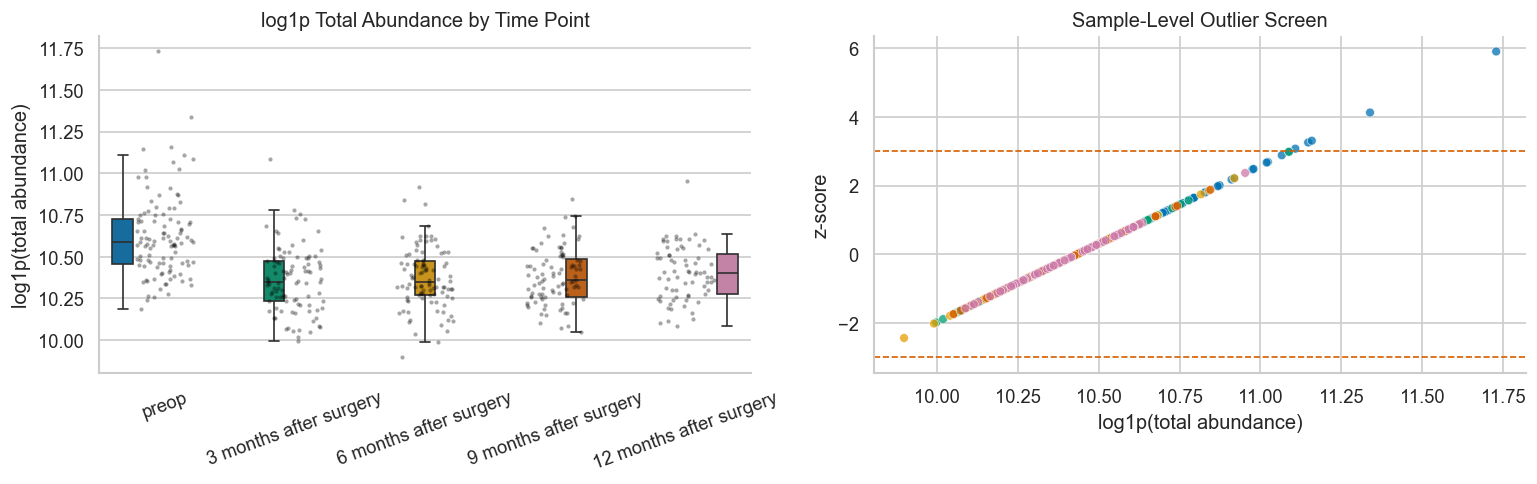

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.boxplot(
    data=df,
    x='time_point',
    y='log_total_abundance',
    hue='time_point',
    order=TIME_ORDER,
    palette=TIME_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[0],
)
sns.stripplot(
    data=df,
    x='time_point',
    y='log_total_abundance',
    order=TIME_ORDER,
    color='black',
    alpha=0.35,
    size=2.5,
    jitter=0.22,
    ax=axes[0],
)
axes[0].set_title('log1p Total Abundance by Time Point')
axes[0].set_xlabel('')
axes[0].set_ylabel('log1p(total abundance)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].scatter(
    df['log_total_abundance'],
    df['profile_z'],
    c=df['time_point'].map(TIME_PALETTE),
    s=28,
    alpha=0.75,
    edgecolor='white',
    linewidth=0.4,
)
axes[1].axhline(3, color='#D55E00', linestyle='--', linewidth=1)
axes[1].axhline(-3, color='#D55E00', linestyle='--', linewidth=1)
axes[1].set_title('Sample-Level Outlier Screen')
axes[1].set_xlabel('log1p(total abundance)')
axes[1].set_ylabel('z-score')

plt.tight_layout()
plt.show()


## 8. PCA on log1p + Standardized Metabolites

PCA ใช้ `log1p` แล้ว standardize แบบ z-score ต่อ metabolite เพื่อให้ metabolite ทุกตัวมี scale ใกล้กัน ไม่ให้ตัวที่มี abundance สูงมากครอบงำแกน PCA. สีของจุดคือ time point.


,variance_explained_pct
PC1,22.12
PC2,10.59
PC3,10.39
PC4,7.66
PC5,6.21


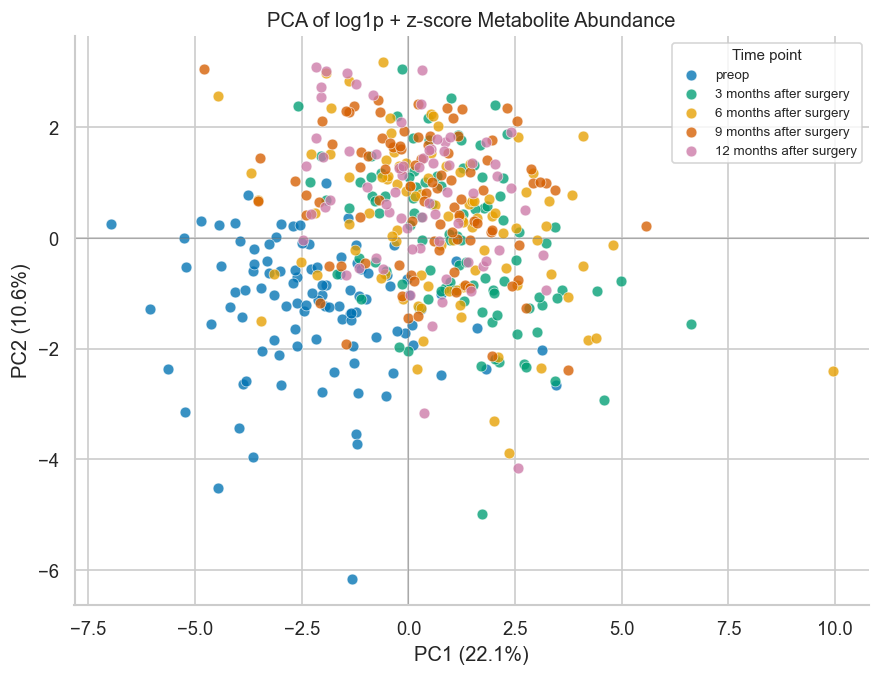

In [32]:
X_scaled = standardize_matrix(df_log[metabs])
pca_scores, explained_ratio, pca_components = pca_via_svd(X_scaled, n_components=min(5, len(metabs)))

pca_df = df[['Sample Name', 'subject_id', 'time_point', 'time_order']].copy()
pca_df['PC1'] = pca_scores[:, 0]
pca_df['PC2'] = pca_scores[:, 1]

explained = pd.Series(
    explained_ratio * 100,
    index=[f'PC{i+1}' for i in range(len(explained_ratio))],
    name='variance_explained_pct',
)
display(explained.round(2).to_frame())

fig, ax = plt.subplots(figsize=(7.5, 5.8))
for time_point in TIME_ORDER:
    plot_data = pca_df[pca_df['time_point'] == time_point]
    ax.scatter(
        plot_data['PC1'],
        plot_data['PC2'],
        label=time_point,
        color=TIME_PALETTE[time_point],
        s=42,
        alpha=0.78,
        edgecolor='white',
        linewidth=0.4,
    )

ax.axhline(0, color='grey', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.7, alpha=0.5)
ax.set_title('PCA of log1p + z-score Metabolite Abundance')
ax.set_xlabel(f'PC1 ({explained.iloc[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained.iloc[1]:.1f}%)')
ax.legend(title='Time point', frameon=True, fontsize=8, title_fontsize=9, loc='best')
plt.tight_layout()
plt.show()


In [33]:
loadings = pd.DataFrame(
    pca_components.T,
    index=metabs,
    columns=[f'PC{i+1}' for i in range(pca_components.shape[0])],
)

pc1_top = loadings['PC1'].abs().sort_values(ascending=False).head(8).index
pc2_top = loadings['PC2'].abs().sort_values(ascending=False).head(8).index

print('Top absolute loadings for PC1')
display(loadings.loc[pc1_top, ['PC1']].sort_values('PC1'))

print('Top absolute loadings for PC2')
display(loadings.loc[pc2_top, ['PC2']].sort_values('PC2'))


Top absolute loadings for PC1


,PC1
L-allo-Isoleucine,-0.374941
L-valine,-0.367780
L-tyrosine,-0.353795
L-leucine,-0.343572
D-phenylalanine,-0.330903
L-alanine,-0.277423
lipoproteins,-0.246901
(R)-3-Hydroxybutyric acid,0.240518


Top absolute loadings for PC2


,PC2
lipoproteins,-0.266014
histidine,0.227845
hypoxanthine,0.230946
L-Lactic acid,0.234684
L-alanine,0.253382
L-glutamine,0.387552
Dimethyl sulfone,0.391213
glycine,0.453297


## 9. Heatmap of Standardized Metabolites

Heatmap นี้แสดง median z-score ของแต่ละ metabolite ในแต่ละ time point หลัง `log1p + standardization`. สีแดงหมายถึงสูงกว่าค่าเฉลี่ยโดยรวมของ metabolite นั้น และสีน้ำเงินหมายถึงต่ำกว่า ค่าใน heatmap จึงเหมาะสำหรับดู pattern ตามเวลา ไม่ใช่ raw abundance.


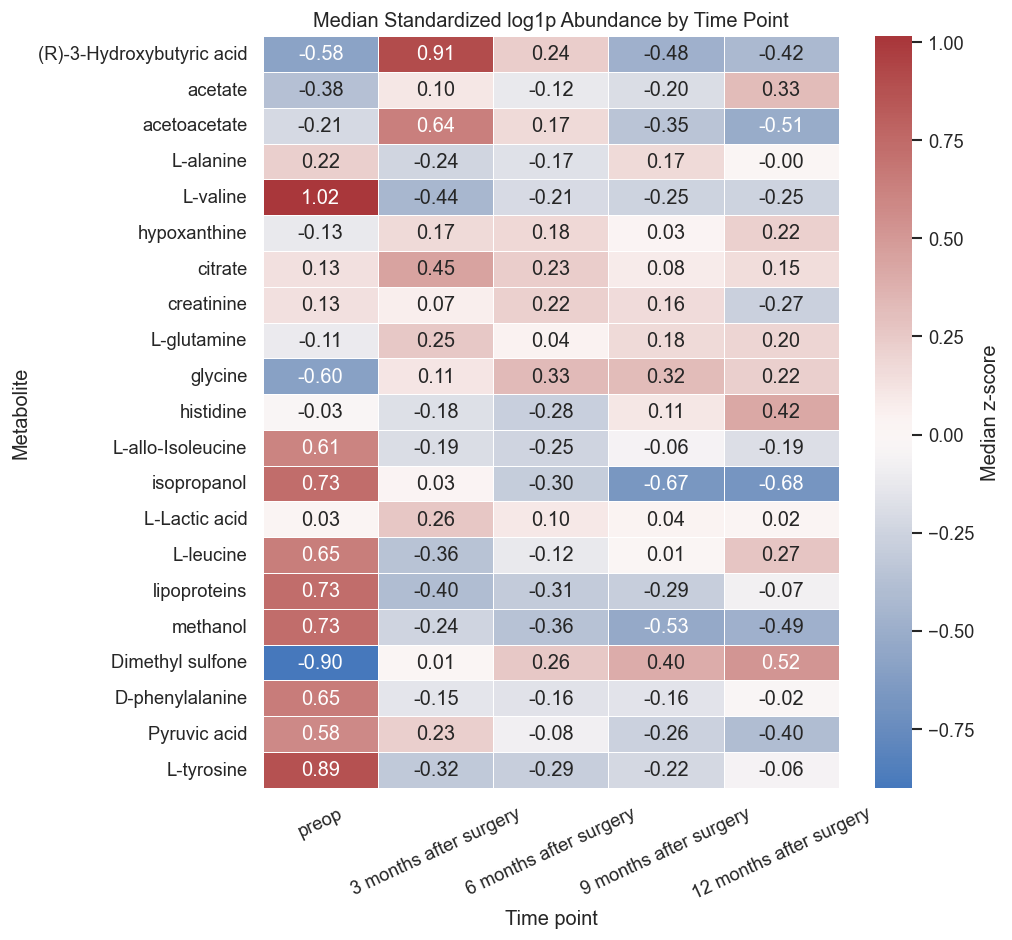

In [34]:
zscore_df = pd.DataFrame(X_scaled, columns=metabs)
zscore_df['time_point'] = df['time_point'].to_numpy()

median_z_by_time = (
    zscore_df.groupby('time_point', observed=True)[metabs]
    .median()
    .reindex(TIME_ORDER)
    .T
)

fig, ax = plt.subplots(figsize=(8.5, 8))
sns.heatmap(
    median_z_by_time,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.35,
    cbar_kws={'label': 'Median z-score'},
    ax=ax,
)
ax.set_title('Median Standardized log1p Abundance by Time Point')
ax.set_xlabel('Time point')
ax.set_ylabel('Metabolite')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## 10. Boxplots for Most Variable Metabolites

เพื่อให้กราฟอ่านง่าย เลือก metabolite ที่มี coefficient of variation สูงสุด 6 ตัวมาดู distribution แยก time point ก่อน ถ้าต้องการเล่า story เพิ่ม สามารถเปลี่ยน `top_variable_metabs` เป็น metabolite ที่สนใจเชิงชีวภาพได้.


Top variable metabolites by coefficient of variation:


,cv
(R)-3-Hydroxybutyric acid,1.964
isopropanol,1.295
acetoacetate,1.075
Dimethyl sulfone,0.863
hypoxanthine,0.812
methanol,0.667


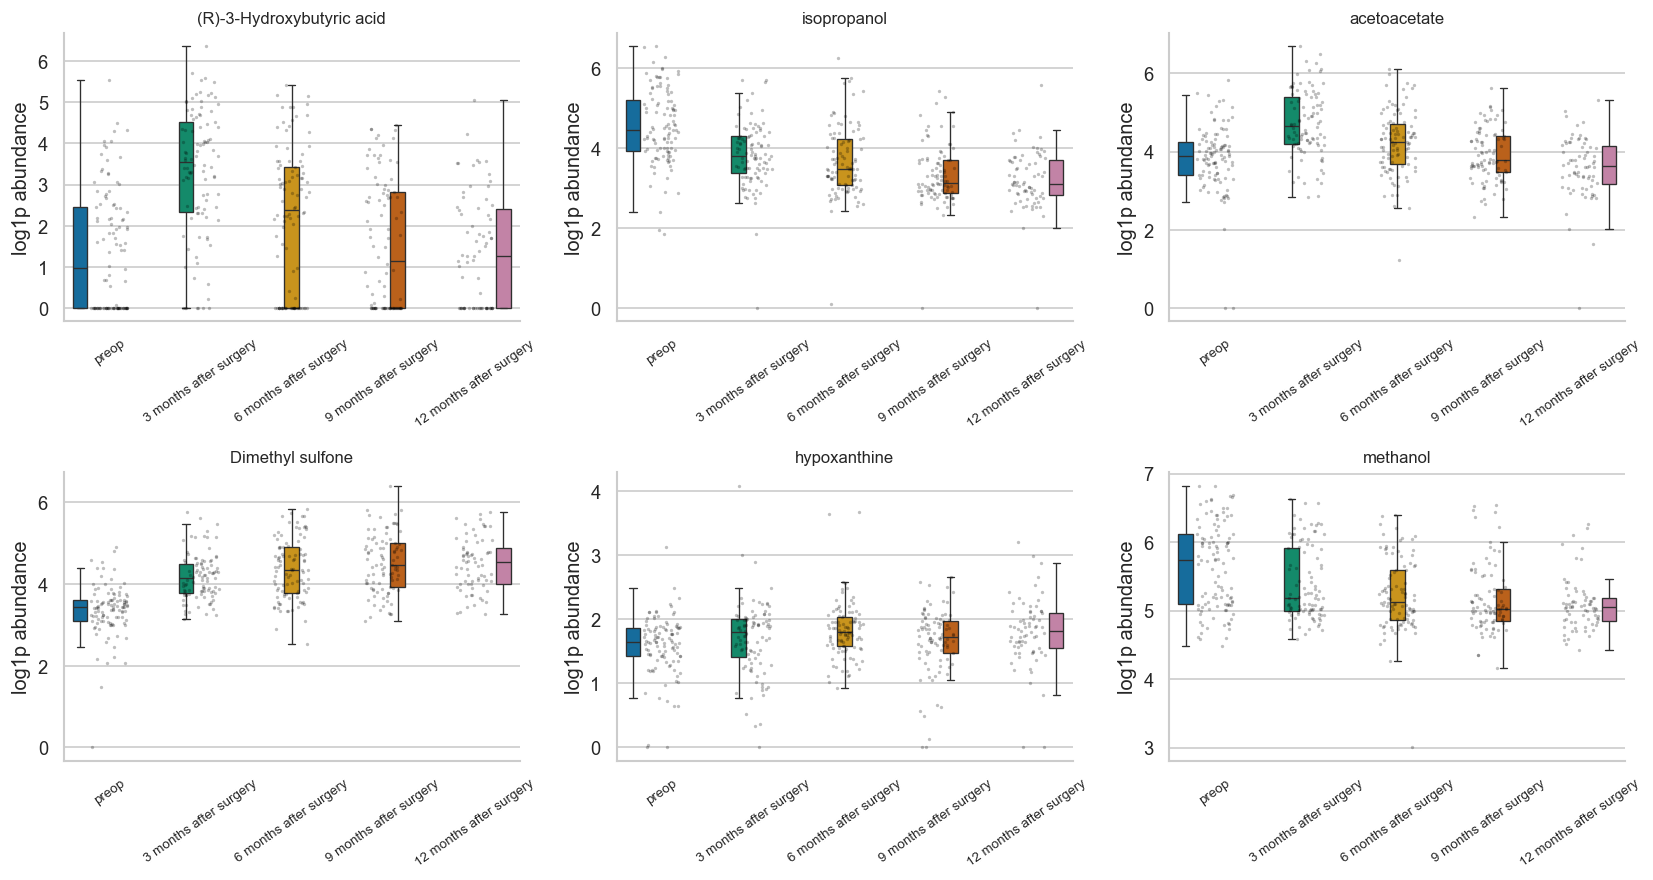

In [35]:
cv = (df[metabs].std() / df[metabs].mean()).sort_values(ascending=False)
top_variable_metabs = cv.head(6).index.tolist()
print('Top variable metabolites by coefficient of variation:')
display(cv.head(6).round(3).rename('cv').to_frame())

plot_data = long_log[long_log['metabolite'].isin(top_variable_metabs)].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharey=False)
axes = axes.ravel()

for ax, metabolite in zip(axes, top_variable_metabs):
    sub = plot_data[plot_data['metabolite'] == metabolite]
    sns.boxplot(
        data=sub,
        x='time_point',
        y='log1p_abundance',
        hue='time_point',
        order=TIME_ORDER,
        palette=TIME_PALETTE,
        showfliers=False,
        linewidth=0.8,
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x='time_point',
        y='log1p_abundance',
        order=TIME_ORDER,
        color='black',
        alpha=0.25,
        size=2,
        jitter=0.2,
        ax=ax,
    )
    ax.set_title(metabolite, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('log1p abundance')
    ax.tick_params(axis='x', rotation=35, labelsize=8)

plt.tight_layout()
plt.show()


## 11. Spaghetti Plots for Paired Trends

Spaghetti plot ช่วยดู within-subject trend โดยเส้นสีเทาคือ subject ที่มีครบทั้ง 5 time points และเส้นสีดำคือ median ของกลุ่ม ถ้าเส้นส่วนใหญ่เปลี่ยนไปทิศเดียวกัน จะเป็นสัญญาณว่าการเปลี่ยนแปลงไม่ได้เกิดจาก sample บางคนเท่านั้น.


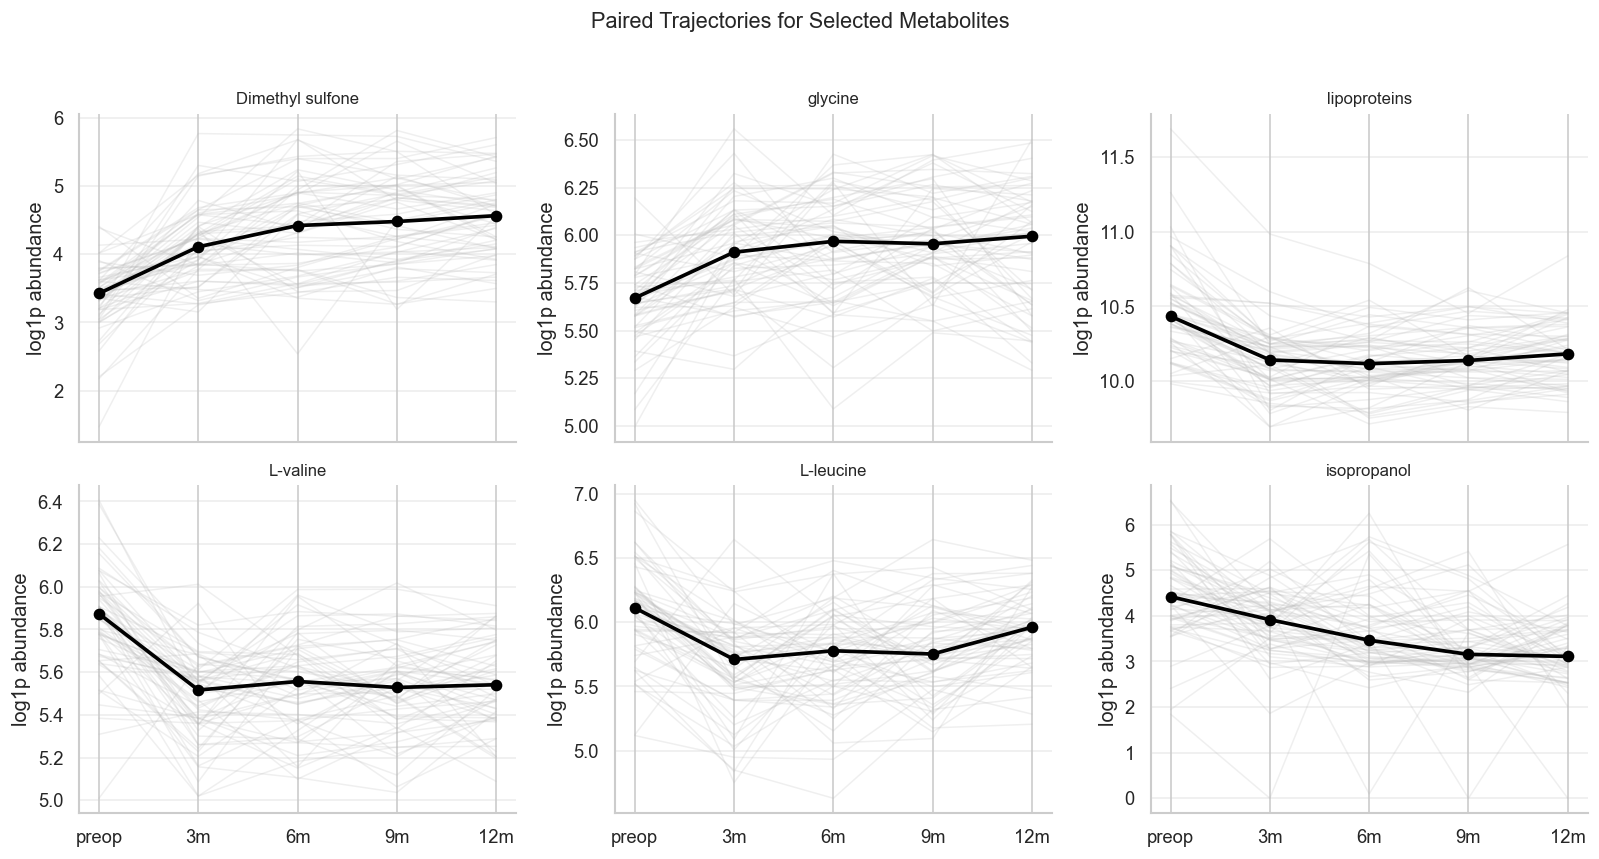

In [36]:
def plot_spaghetti(ax, metabolite, data=df_log, time_order=TIME_ORDER):
    wide = (
        data.pivot_table(index='subject_id', columns='time_point', values=metabolite, aggfunc='mean', observed=True)
        .reindex(columns=time_order)
    )
    complete = wide.dropna()
    x = np.arange(len(time_order))

    for _, row in complete.iterrows():
        ax.plot(x, row.values, color='0.72', alpha=0.22, linewidth=0.9)

    median_line = complete.median(axis=0)
    ax.plot(x, median_line.values, color='black', marker='o', linewidth=2.2, label='Median')
    ax.set_xticks(x)
    ax.set_xticklabels(['preop', '3m', '6m', '9m', '12m'])
    ax.set_title(metabolite, fontsize=10)
    ax.set_ylabel('log1p abundance')
    ax.set_xlabel('')
    ax.grid(True, axis='y', alpha=0.35)

selected_metabs = [
    'Dimethyl sulfone',
    'glycine',
    'lipoproteins',
    'L-valine',
    'L-leucine',
    'isopropanol',
]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7), sharex=True)
for ax, metabolite in zip(axes.ravel(), selected_metabs):
    plot_spaghetti(ax, metabolite)

fig.suptitle('Paired Trajectories for Selected Metabolites', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 12. Repeated-Measures Statistics

เพราะข้อมูลเป็น longitudinal repeated-measures จึงควรใช้สถิติที่รักษา pairing ของ subject:
- Friedman test: ใช้เฉพาะ subject ที่มีครบทั้ง 5 time points เพื่อทดสอบว่ามีการเปลี่ยนแปลงโดยรวมตามเวลาหรือไม่
- Wilcoxon signed-rank: เทียบแต่ละ post-op time point กับ preop โดยใช้เฉพาะคู่ subject ที่มีข้อมูลครบสองเวลานั้น
- FDR correction: ใช้ Benjamini-Hochberg เพื่อควบคุม multiple testing ระดับ metabolite


ถ้า kernel ไม่มี `scipy` notebook จะใช้ fallback ที่เขียนด้วย NumPy/Pandas: Friedman ใช้ chi-square approximation และ Wilcoxon ใช้ normal approximation ดังนั้นค่า p-value อาจต่างจาก SciPy เล็กน้อย แต่ direction/effect size และ EDA ยังใช้ได้สำหรับ hackathon/prototype.

หมายเหตุ: ผลสถิตินี้เป็น exploratory analysis ไม่ใช่ causal conclusion และควรตีความร่วมกับ effect size/กราฟ.


In [37]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)
    valid = np.isfinite(p_values)
    p = p_values[valid]
    m = len(p)
    if m == 0:
        return q_values

    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]

    reordered = np.empty(m, dtype=float)
    reordered[order] = np.minimum(adjusted, 1.0)
    q_values[valid] = reordered
    return q_values

friedman_rows = []
for metabolite in metabs:
    wide = (
        df_log.pivot_table(index='subject_id', columns='time_point', values=metabolite, aggfunc='mean', observed=True)
        .reindex(columns=TIME_ORDER)
        .dropna()
    )
    try:
        stat, p_value = friedman_test(*[wide[col].values for col in TIME_ORDER])
    except ValueError:
        stat, p_value = np.nan, np.nan

    raw_wide = (
        df.pivot_table(index='subject_id', columns='time_point', values=metabolite, aggfunc='mean', observed=True)
        .reindex(columns=TIME_ORDER)
        .loc[wide.index]
    )
    friedman_rows.append({
        'metabolite': metabolite,
        'n_complete_subjects': len(wide),
        'friedman_stat': stat,
        'p_value': p_value,
        'preop_median_raw': raw_wide['preop'].median(),
        '12m_median_raw': raw_wide['12 months after surgery'].median(),
        'median_delta_12m_minus_preop_raw': raw_wide['12 months after surgery'].median() - raw_wide['preop'].median(),
        'test_method': 'friedman_scipy' if SCIPY_AVAILABLE else 'friedman_fallback_chi_square_approx',
    })

friedman_results = pd.DataFrame(friedman_rows)
friedman_results['q_value_fdr'] = benjamini_hochberg(friedman_results['p_value'])
friedman_results = friedman_results.sort_values(['q_value_fdr', 'p_value', 'metabolite'])

display(friedman_results.round(4))
friedman_results.to_csv(OUTPUT_DIR / 'friedman_results.csv', index=False)


,metabolite,n_complete_subjects,friedman_stat,p_value,preop_median_raw,12m_median_raw,median_delta_12m_minus_preop_raw,test_method,q_value_fdr
17,Dimethyl sulfone,60,97.6267,0.0000,29.7173,94.9089,65.1915,friedman_fallback_chi_square_approx,0.0000
15,lipoproteins,60,94.8800,0.0000,33972.0606,26394.7675,-7577.2931,friedman_fallback_chi_square_approx,0.0000
9,glycine,60,76.5200,0.0000,289.1884,400.2923,111.1039,friedman_fallback_chi_square_approx,0.0000
14,L-leucine,60,76.2267,0.0000,449.9036,386.7608,-63.1429,friedman_fallback_chi_square_approx,0.0000
4,L-valine,60,65.9333,0.0000,354.5540,254.0136,-100.5403,friedman_fallback_chi_square_approx,0.0000
12,isopropanol,60,59.3995,0.0000,82.1707,21.4559,-60.7148,friedman_fallback_chi_square_approx,0.0000
2,acetoacetate,60,53.5067,0.0000,53.8277,36.9788,-16.8490,friedman_fallback_chi_square_approx,0.0000
20,L-tyrosine,60,52.6800,0.0000,128.0152,99.7932,-28.2220,friedman_fallback_chi_square_approx,0.0000
0,(R)-3-Hydroxybutyric acid,60,48.4850,0.0000,3.3463,2.7649,-0.5815,friedman_fallback_chi_square_approx,0.0000
11,L-allo-Isoleucine,60,46.4933,0.0000,55.0217,45.7492,-9.2725,friedman_fallback_chi_square_approx,0.0000


In [ ]:
pairwise_rows = []
for target_time in TIME_ORDER[1:]:
    for metabolite in metabs:
        wide = (
            df_log.pivot_table(index='subject_id', columns='time_point', values=metabolite, aggfunc='mean', observed=True)
            .reindex(columns=['preop', target_time])
            .dropna()
        )
        raw_wide = (
            df.pivot_table(index='subject_id', columns='time_point', values=metabolite, aggfunc='mean', observed=True)
            .reindex(columns=['preop', target_time])
            .loc[wide.index]
        )

        try:
            stat, p_value, method = paired_wilcoxon_test(wide[target_time], wide['preop'])
        except ValueError:
            stat, p_value, method = np.nan, np.nan, 'wilcoxon_failed'

        pairwise_rows.append({
            'comparison': f'{target_time} vs preop',
            'target_time': target_time,
            'metabolite': metabolite,
            'n_pairs': len(wide),
            'wilcoxon_stat': stat,
            'p_value': p_value,
            'median_log1p_delta': (wide[target_time] - wide['preop']).median(),
            'median_raw_delta': (raw_wide[target_time] - raw_wide['preop']).median(),
            'test_method': method,
        })

pairwise_results = pd.DataFrame(pairwise_rows)
pairwise_results['q_value_fdr'] = np.nan
for comparison, idx in pairwise_results.groupby('comparison').groups.items():
    pairwise_results.loc[idx, 'q_value_fdr'] = benjamini_hochberg(pairwise_results.loc[idx, 'p_value'])

pairwise_results = pairwise_results.sort_values(['comparison', 'q_value_fdr', 'p_value', 'metabolite'])
display(pairwise_results.round(4))
pairwise_results.to_csv(OUTPUT_DIR / 'wilcoxon_preop_vs_postop_results.csv', index=False)


,comparison,target_time,metabolite,n_pairs,wilcoxon_stat,p_value,median_log1p_delta,median_raw_delta,test_method,q_value_fdr
80,12 months after surgery vs preop,12 months after surgery,Dimethyl sulfone,71,91.0,0.0000,1.0895,55.8585,wilcoxon_fallback_normal_approx,0.0000
75,12 months after surgery vs preop,12 months after surgery,isopropanol,71,143.0,0.0000,-1.2085,-61.9394,wilcoxon_fallback_normal_approx,0.0000
67,12 months after surgery vs preop,12 months after surgery,L-valine,71,161.0,0.0000,-0.3517,-104.7898,wilcoxon_fallback_normal_approx,0.0000
78,12 months after surgery vs preop,12 months after surgery,lipoproteins,71,177.0,0.0000,-0.1941,-5478.0147,wilcoxon_fallback_normal_approx,0.0000
72,12 months after surgery vs preop,12 months after surgery,glycine,71,242.0,0.0000,0.2299,70.0002,wilcoxon_fallback_normal_approx,0.0000
83,12 months after surgery vs preop,12 months after surgery,L-tyrosine,71,280.0,0.0000,-0.1863,-22.0862,wilcoxon_fallback_normal_approx,0.0000
74,12 months after surgery vs preop,12 months after surgery,L-allo-Isoleucine,71,283.0,0.0000,-0.2270,-11.5021,wilcoxon_fallback_normal_approx,0.0000
82,12 months after surgery vs preop,12 months after surgery,Pyruvic acid,71,380.0,0.0000,-0.4137,-35.5054,wilcoxon_fallback_normal_approx,0.0000
81,12 months after surgery vs preop,12 months after surgery,D-phenylalanine,71,411.0,0.0000,-0.1322,-20.9621,wilcoxon_fallback_normal_approx,0.0000
79,12 months after surgery vs preop,12 months after surgery,methanol,71,444.0,0.0000,-0.4203,-82.5142,wilcoxon_fallback_normal_approx,0.0000


## 13. Optional: Linear Mixed Model

ถ้าต้องการใช้ข้อมูลทุก subject แม้บางคนขาดบาง time point ให้ใช้ linear mixed model โดยใส่ `subject_id` เป็น random intercept. Cell ด้านล่างเป็น optional เพราะต้องใช้ `statsmodels`; ถ้า package ยังไม่มี Notebook จะ skip ให้อัตโนมัติ.


In [42]:
try:
    import statsmodels.formula.api as smf

    lmm_metabolite = 'Dimethyl sulfone'
    lmm_data = long_log[long_log['metabolite'] == lmm_metabolite].dropna().copy()
    lmm_data['time_point'] = pd.Categorical(lmm_data['time_point'], categories=TIME_ORDER, ordered=True)

    model = smf.mixedlm(
        'log1p_abundance ~ C(time_point, Treatment(reference="preop"))',
        data=lmm_data,
        groups=lmm_data['subject_id'],
    )
    fit = model.fit(reml=False, method='lbfgs')
    print(fit.summary())
except ModuleNotFoundError:
    print('statsmodels is not installed, so the optional mixed model cell was skipped.')
except Exception as exc:
    print(f'Mixed model did not converge or failed for this metabolite: {exc}')


statsmodels is not installed, so the optional mixed model cell was skipped.


## 14. Save Cleaned EDA Tables

บันทึกตารางที่ reshape แล้ว และตาราง log-transformed เพื่อใช้ต่อใน modeling หรือทำ dashboard ภายหลัง.


In [45]:
df.to_csv(OUTPUT_DIR / 'mtbls242_reshaped_sample_by_metabolite.csv', index=False)
df_log.to_csv(OUTPUT_DIR / 'mtbls242_log1p_sample_by_metabolite.csv', index=False)
zero_summary.to_csv(OUTPUT_DIR / 'qc_zero_missing_summary.csv', index=False)

print(f'Saved EDA tables to: {OUTPUT_DIR.resolve()}')


Saved EDA tables to: /Users/nene/Documents/24May_BDIHacKathon/bdi-hackathon-2026-sampled-dataset/nmr-result/eda_outputs


## Suggested Interpretation Notes

จาก EDA เบื้องต้นควรโฟกัสที่ pattern ตามเวลาและการเปลี่ยนแปลงภายใน subject มากกว่าการเปรียบเทียบกลุ่มแบบ independent. Metabolites ที่มักเห็น signal ชัดในชุดข้อมูลนี้ เช่น `Dimethyl sulfone`, `glycine`, `lipoproteins`, `L-valine`, `L-leucine`, และ `isopropanol` ควรถูกตรวจด้วยกราฟ paired trajectory และ paired statistics ก่อนสรุปเชิงชีวภาพ.
